Decision Tree Performance
Accuracy: 32.57%

Classification Report:
              precision    recall  f1-score   support

        Loss       0.05      0.24      0.09        17
     Neutral       0.44      0.57      0.50        49
      Profit       0.66      0.23      0.34       109

    accuracy                           0.33       175
   macro avg       0.38      0.35      0.31       175
weighted avg       0.54      0.33      0.36       175



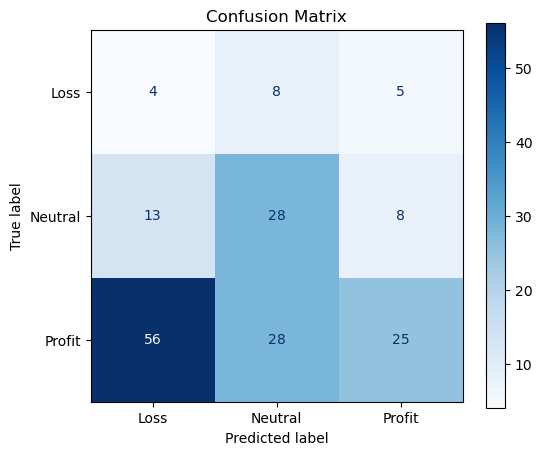


Feature Importance:
       Feature  Importance
     NumTrades    0.338362
  AvgTradeSize    0.319916
       WinRate    0.179703
LongShortRatio    0.131964
       FGValue    0.030055


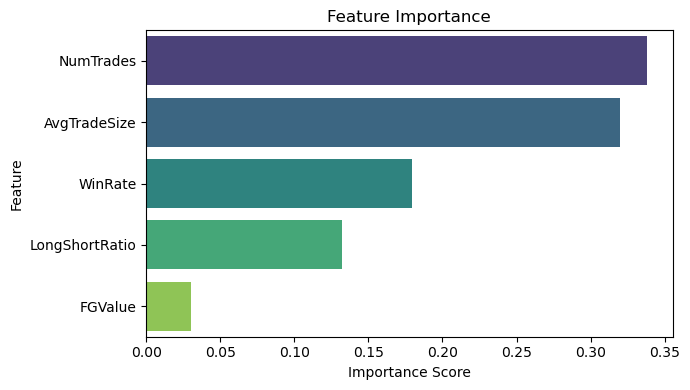

In [4]:
# Predict Next-Day Profitability (Decision Tree)
# Cleaned: Zero-Division Warning Handled

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. Load Datasets
trades = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

# Clean column names (strip trailing spaces)
trades.columns = trades.columns.str.strip()
fg.columns = fg.columns.str.strip()

# 2. Dynamic Column Detection & Standardization
pnl_col = next((c for c in ["Closed PnL", "PnL", "pnl", "closed_pnl"] if c in trades.columns), None)
size_col = next((c for c in ["Size USD", "Size Tokens", "TradeSize", "size_usd", "size"] if c in trades.columns), None)
side_col = next((c for c in ["Side", "Direction", "Type", "side", "direction"] if c in trades.columns), None)
fg_val_col = next((c for c in ["value", "FGValue", "fg_value", "Value"] if c in fg.columns), None)

rename_dict = {}
if pnl_col: rename_dict[pnl_col] = "PnL"
if size_col: rename_dict[size_col] = "TradeSize"
if side_col: rename_dict[side_col] = "Type"

trades = trades.rename(columns=rename_dict)

if fg_val_col:
    fg = fg.rename(columns={fg_val_col: "FGValue"})

if "PnL" not in trades.columns:
    raise KeyError("Could not find a PnL column in historical_data.csv!")
if "TradeSize" not in trades.columns:
    trades["TradeSize"] = 1.0
if "Type" not in trades.columns:
    trades["Type"] = "BUY"

# 3. Data Cleaning & Normalization
timestamp_col = next((c for c in ["Timestamp IST", "Timestamp", "timestamp_ist", "date"] if c in trades.columns), trades.columns[0])
trades["Timestamp IST"] = pd.to_datetime(trades[timestamp_col], errors="coerce")
trades["date"] = trades["Timestamp IST"].dt.normalize()

fg_date_col = next((c for c in ["date", "Timestamp", "timestamp"] if c in fg.columns), fg.columns[0])
fg["date"] = pd.to_datetime(fg[fg_date_col], errors="coerce").dt.normalize()
fg = fg.drop_duplicates("date")

df = trades.merge(fg, on="date", how="left")
df["FGValue"] = df["FGValue"].fillna(df["FGValue"].median() if "FGValue" in df.columns else 50)

# 4. Grouping & Feature Engineering (trader_day)
account_col = "Account" if "Account" in df.columns else ("account" if "account" in df.columns else None)
if not account_col:
    df["Account"] = "Trader_1"
    account_col = "Account"

def calc_ls_ratio(types):
    types_upper = types.astype(str).str.upper()
    buys = (types_upper.isin(["BUY", "LONG"])).sum()
    sells = (types_upper.isin(["SELL", "SHORT"])).sum()
    return buys / sells if sells > 0 else 1.0

trader_day = df.groupby([account_col, "date"]).agg(
    DailyPnL=("PnL", "sum"),
    WinRate=("PnL", lambda x: (x > 0).mean()),
    AvgTradeSize=("TradeSize", "mean"),
    NumTrades=("PnL", "count"),
    LongShortRatio=("Type", calc_ls_ratio),
    FGValue=("FGValue", "first")
).reset_index().rename(columns={account_col: "Account"})

trader_day = trader_day.sort_values(["Account", "date"])

# 5. Create Target Variable
trader_day["NextDayPnL"] = trader_day.groupby("Account")["DailyPnL"].shift(-1)

trader_day["ProfitBucket"] = pd.cut(
    trader_day["NextDayPnL"],
    bins=[-np.inf, -1, 1, np.inf],
    labels=["Loss", "Neutral", "Profit"]
)

label_map = {"Loss": 0, "Neutral": 1, "Profit": 2}
trader_day["Target"] = trader_day["ProfitBucket"].map(label_map)

# 6. Select Features & Clean Target
features = [
    "WinRate",
    "AvgTradeSize",
    "NumTrades",
    "LongShortRatio",
    "FGValue"
]

ml_data = trader_day[features + ["Target"]].dropna().copy()
ml_data["Target"] = ml_data["Target"].astype(int)

# 7. Split & Train Model
X = ml_data[features]
y = ml_data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 else None
)

# Added class_weight="balanced" to help the tree predict minority classes
model = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# 8. Evaluation & Outputs
pred = model.predict(X_test)

print("=" * 45)
print("Decision Tree Performance")
print("=" * 45)
print(f"Accuracy: {accuracy_score(y_test, pred):.2%}\n")

# Label mapping based on active classes in test set
all_labels = ["Loss", "Neutral", "Profit"]
unique_targets = sorted(y_test.unique())
target_names = [all_labels[i] for i in unique_targets]

print("Classification Report:")
# Added zero_division=0 to suppress metric warnings cleanly
print(classification_report(
    y_test,
    pred,
    target_names=target_names,
    zero_division=0
))

# Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=target_names,
    cmap="Blues",
    ax=ax
)
plt.title("Confusion Matrix")
plt.show()

# Feature Importance Plot
importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print("\nFeature Importance:")
print(importance.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()